<a href="https://colab.research.google.com/github/kanchan25003125-source/mle_case_study/blob/main/case_study_2_mle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
!pip install xgboost imbalanced-learn

In [ ]:
df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11959, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print(df["Class"].value_counts())

print("\nFraud percentage:",
      round(df["Class"].mean() * 100, 2), "%")

Class
0.0    11906
1.0       52
Name: count, dtype: int64

Fraud percentage: 0.43 %


In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

valid_rows = y.notna()

X = X[valid_rows]
y = y[valid_rows]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (11958, 30)
Target: (11958,)


In [ ]:
# Train / validation split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9566, 30)
Testing data: (2392, 30)


In [ ]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0.0    9524
1.0      42
Name: count, dtype: int64

After SMOTE:
Class
0.0    9524
1.0    9524
Name: count, dtype: int64


In [ ]:
# XGBoost model
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train_smote, y_train_smote)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Prediction probabilities
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9922753988245172


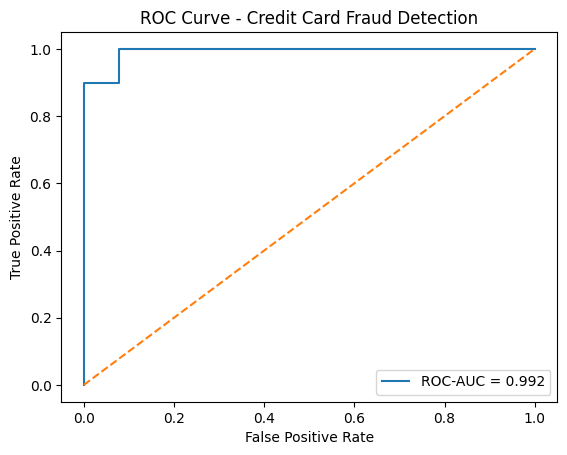

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.show()

In [ ]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred
    ).ravel()

    recall = tp / (tp + fn)

    print(
        "Threshold:", threshold,
        "| Recall:", round(recall, 3),
        "| FP:", fp,
        "| FN:", fn
    )

Threshold: 0.3 | Recall: 0.9 | FP: 2 | FN: 1
Threshold: 0.4 | Recall: 0.9 | FP: 0 | FN: 1
Threshold: 0.5 | Recall: 0.9 | FP: 0 | FN: 1
Threshold: 0.6 | Recall: 0.9 | FP: 0 | FN: 1
Threshold: 0.7 | Recall: 0.8 | FP: 0 | FN: 2


In [ ]:
threshold = 0.4

y_pred = (y_prob >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test, y_pred
).ravel()

print("Selected Threshold:", threshold)
print("True Positive :", tp)
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)

Selected Threshold: 0.4
True Positive : 9
True Negative : 2382
False Positive: 0
False Negative: 1


In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

V12       0.739541
Time      0.045955
V14       0.032543
Amount    0.032531
V4        0.031797
V6        0.027629
V9        0.021483
V11       0.017085
V10       0.012665
V16       0.007517
dtype: float32


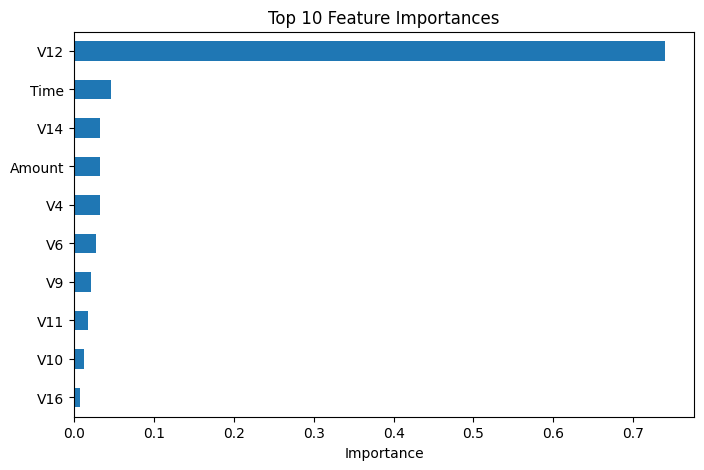

In [ ]:
importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()